In [4]:
import pandas as pd

df = pd.read_csv("StudentPerformanceFactors.csv")

In [5]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [7]:
#Check missing values before imputation
print("Missing values before imputation:")
print(df.isnull().sum())
print(f"\nTotal rows: {df.shape[0]}")

Missing values before imputation:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Total rows: 6607


In [8]:
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(df["Teacher_Quality"].mode()[0])
df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(df["Parental_Education_Level"].mode()[0])
df["Distance_from_Home"] = df["Distance_from_Home"].fillna(df["Distance_from_Home"].mode()[0])

In [9]:
#Verify — no more missing values
print("\nMissing values AFTER imputation:")
print(df.isnull().sum())



Missing values AFTER imputation:
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [11]:
df.select_dtypes(include=['object', 'string']).columns

Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='str')

In [14]:
print(df["Teacher_Quality"].unique().tolist())
print(df["Parental_Education_Level"].unique().tolist())
print(df["Distance_from_Home"].unique().tolist())

['Medium', 'High', 'Low']
['High School', 'College', 'Postgraduate']
['Near', 'Moderate', 'Far']


In [15]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df.shape)
print(df_encoded.shape)

(6607, 20)
(6607, 28)


In [60]:
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)


print("Data types:")
print(df_encoded.dtypes)

Data types:
Hours_Studied                            float64
Attendance                               float64
Sleep_Hours                              float64
Previous_Scores                          float64
Tutoring_Sessions                        float64
Physical_Activity                        float64
Exam_Score                                 int64
Parental_Involvement_Low                   int64
Parental_Involvement_Medium                int64
Access_to_Resources_Low                    int64
Access_to_Resources_Medium                 int64
Extracurricular_Activities_Yes             int64
Motivation_Level_Low                       int64
Motivation_Level_Medium                    int64
Internet_Access_Yes                        int64
Family_Income_Low                          int64
Family_Income_Medium                       int64
Teacher_Quality_Low                        int64
Teacher_Quality_Medium                     int64
School_Type_Public                         int64
Peer_Inf

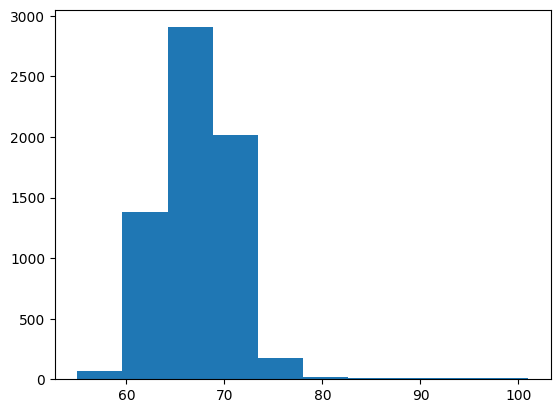

Mean: 67.23565914938702
Median: 67.0
Std: 3.890455781261732


In [27]:
import matplotlib.pyplot as plt

plt.hist(df_encoded["Exam_Score"])
plt.show()

print("Mean:", df_encoded["Exam_Score"].mean())
print("Median:", df_encoded["Exam_Score"].median())
print("Std:", df_encoded["Exam_Score"].std())

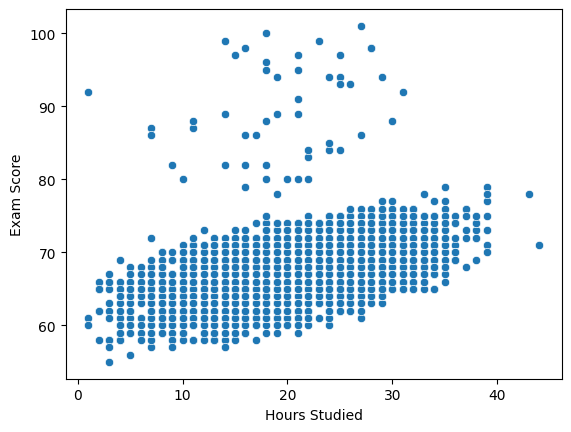

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df_encoded["Hours_Studied"], y=df_encoded["Exam_Score"])

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()

In [33]:
features = df_encoded.drop("Exam_Score", axis=1)

In [66]:
corr = features.corr()
print(corr)

                                       Hours_Studied  Attendance  Sleep_Hours  \
Hours_Studied                               1.000000   -0.009908     0.010977   
Attendance                                 -0.009908    1.000000    -0.015918   
Sleep_Hours                                 0.010977   -0.015918     1.000000   
Previous_Scores                             0.024846   -0.020186    -0.021750   
Tutoring_Sessions                          -0.014282    0.014324    -0.012216   
Physical_Activity                           0.004624   -0.022435    -0.000378   
Parental_Involvement_Low                    0.013395    0.014296     0.008250   
Parental_Involvement_Medium                 0.000856   -0.010021    -0.002207   
Access_to_Resources_Low                     0.012119    0.012798     0.020371   
Access_to_Resources_Medium                 -0.011730   -0.004356    -0.012259   
Extracurricular_Activities_Yes             -0.006017   -0.002222     0.001379   
Motivation_Level_Low        

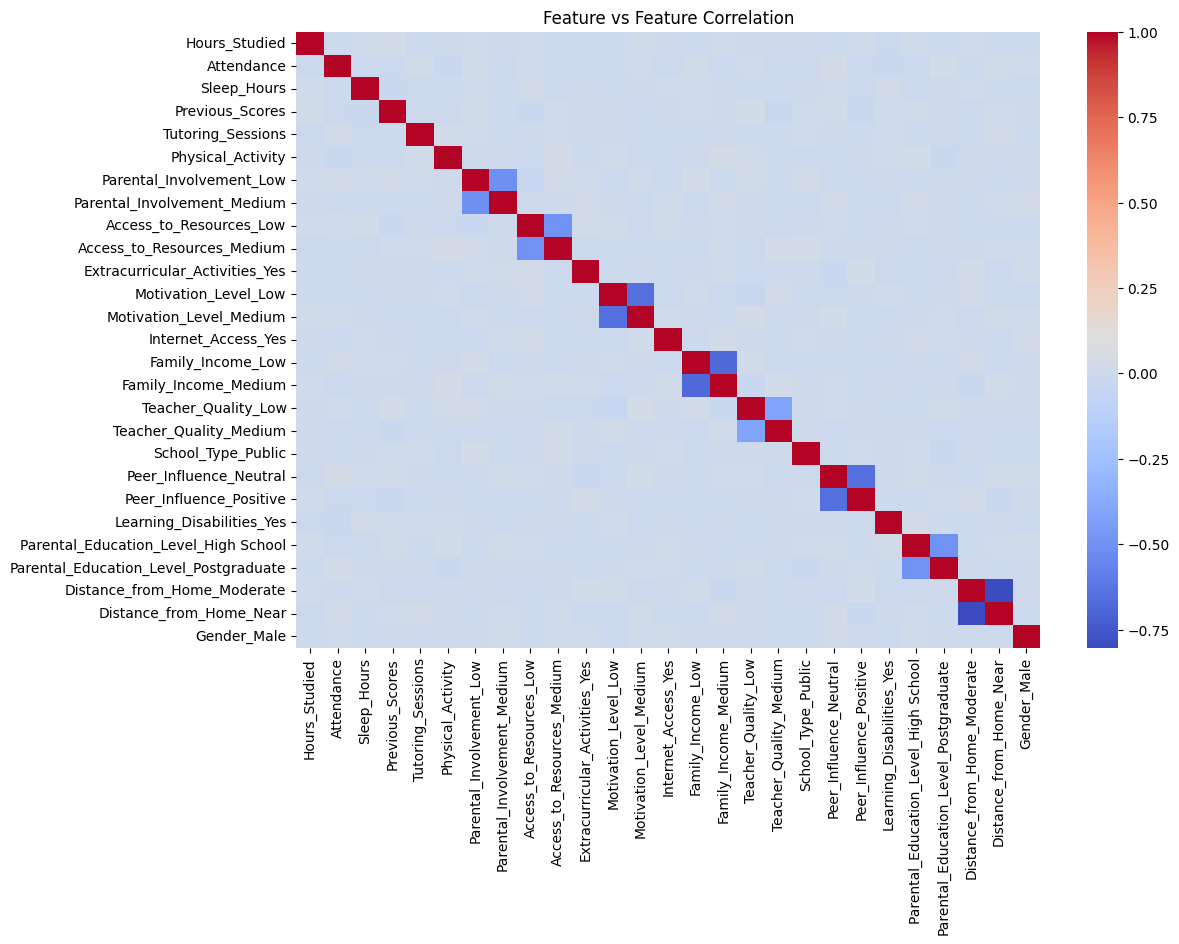

In [67]:
features = df_encoded.drop("Exam_Score", axis=1)

plt.figure(figsize=(12,8))
sns.heatmap(features.corr(), cmap="coolwarm")
plt.title("Feature vs Feature Correlation")
plt.show()


In [42]:
print("\nCorrelation with Exam_Score:")
correlation = df_encoded.corr()["Exam_Score"]
print(correlation.sort_values(ascending=False))


Correlation with Exam_Score:
Exam_Score                               1.000000
Attendance                               0.660555
Hours_Studied                            0.504766
Previous_Scores                          0.195737
Tutoring_Sessions                        0.175254
Parental_Education_Level_Postgraduate    0.109123
Distance_from_Home_Near                  0.091775
Peer_Influence_Positive                  0.091139
Extracurricular_Activities_Yes           0.068166
Internet_Access_Yes                      0.063424
Physical_Activity                        0.037263
Motivation_Level_Medium                  0.028631
Family_Income_Medium                     0.027721
Gender_Male                              0.004369
Peer_Influence_Neutral                  -0.009333
School_Type_Public                      -0.012251
Sleep_Hours                             -0.014136
Access_to_Resources_Medium              -0.031501
Parental_Involvement_Medium             -0.033253
Teacher_Quality_Medi

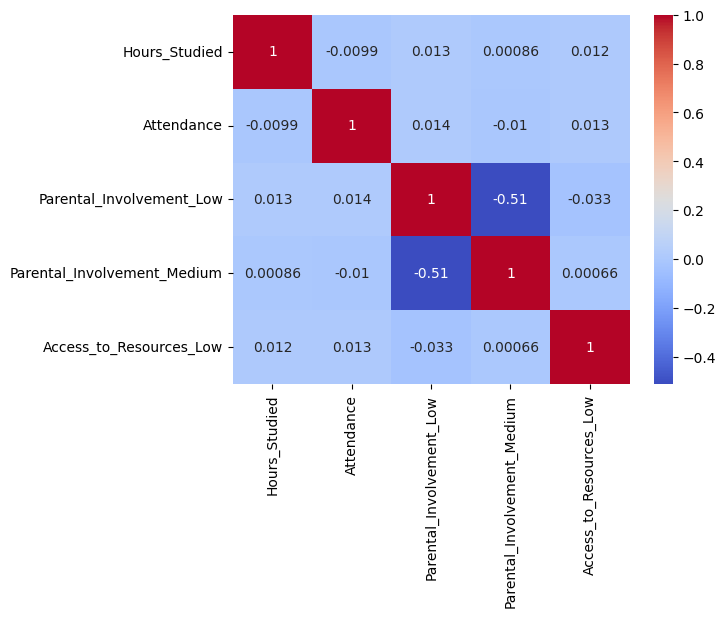

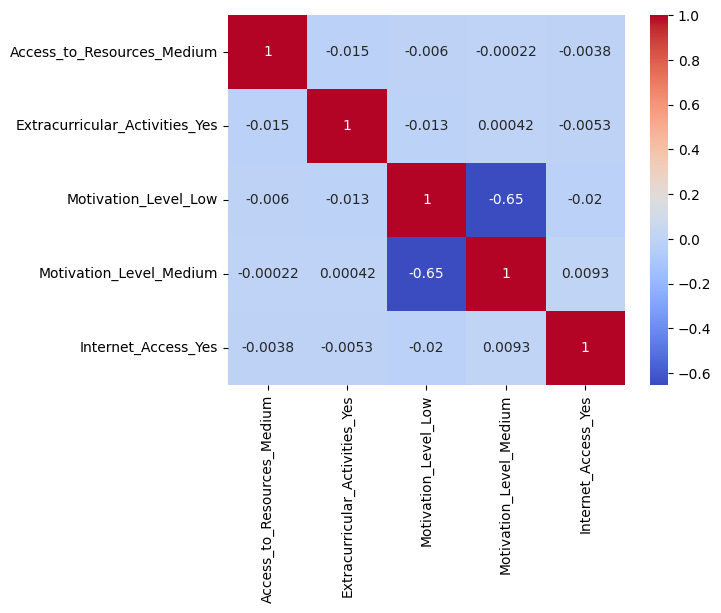

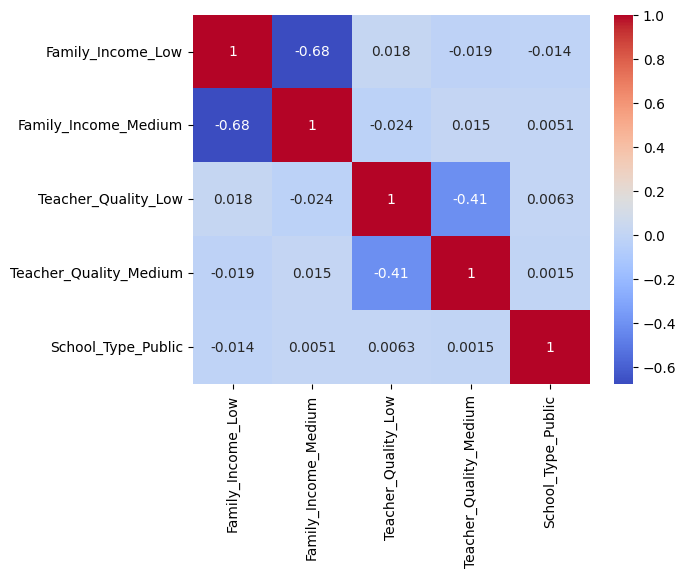

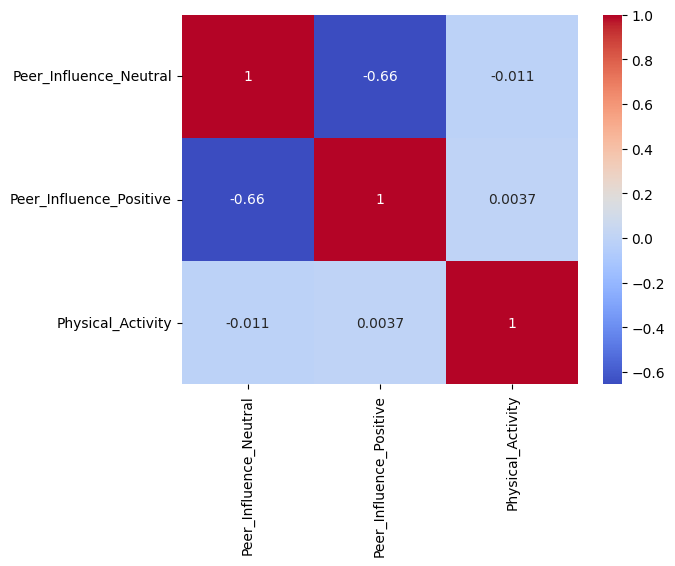

In [54]:
cols1 = ["Hours_Studied", "Attendance", "Parental_Involvement_Low", "Parental_Involvement_Medium", 
         "Access_to_Resources_Low"]
sns.heatmap(df_encoded[cols1].corr(), annot=True, cmap="coolwarm")
plt.show()

cols2 = ["Access_to_Resources_Medium", "Extracurricular_Activities_Yes", "Motivation_Level_Low",
         "Motivation_Level_Medium", "Internet_Access_Yes"]
sns.heatmap(df_encoded[cols2].corr(), annot=True, cmap="coolwarm")
plt.show()

cols3 = ["Family_Income_Low", "Family_Income_Medium", "Teacher_Quality_Low", "Teacher_Quality_Medium",
         "School_Type_Public"]
sns.heatmap(df_encoded[cols3].corr(), annot=True, cmap="coolwarm")
plt.show()

cols4 = ["Peer_Influence_Neutral", "Peer_Influence_Positive", "Physical_Activity"]
sns.heatmap(df_encoded[cols4].corr(), annot=True, cmap="coolwarm")
plt.show()

In [43]:
from sklearn.ensemble import RandomForestRegressor

X = df_encoded.drop("Exam_Score", axis=1)
y = df_encoded["Exam_Score"]

In [44]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance_sorted = importance.sort_values(ascending=False)

print("\nTop Features (Random Forest):")
print(importance_sorted.head(10))



Top Features (Random Forest):
Attendance                   0.456029
Hours_Studied                0.276007
Previous_Scores              0.066405
Tutoring_Sessions            0.032703
Access_to_Resources_Low      0.021096
Parental_Involvement_Low     0.020567
Physical_Activity            0.014398
Sleep_Hours                  0.012526
Peer_Influence_Positive      0.007978
Learning_Disabilities_Yes    0.007768
dtype: float64


In [62]:
threshold = 0.02
top_features = importance_sorted[importance_sorted >= threshold].index.tolist()
print(f"Selected {len(top_features)} features: {top_features}")


Selected 6 features: ['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Access_to_Resources_Low', 'Parental_Involvement_Low']


In [63]:
df_final = df_encoded[top_features + ["Exam_Score"]]

print("\nFinal dataset shape:", df_final.shape)
print("Final features:", top_features)


Final dataset shape: (6607, 7)
Final features: ['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Access_to_Resources_Low', 'Parental_Involvement_Low']


In [64]:
df_final.to_csv("student_performance_clean.csv", index=False)

print("\nSaved as 'student_performance_clean.csv'")


Saved as 'student_performance_clean.csv'
